In [1]:
!pip install timm -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
data_dir = "/kaggle/input/datasets/nayemsiddiki/skindiseasebd/SkinDiseaseBD A Dataset of Common Skin Disease Ima/Updated Images"

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [6]:
full_dataset = datasets.ImageFolder(root=data_dir)
class_names = full_dataset.classes
num_classes = len(class_names)

indices = np.arange(len(full_dataset))
np.random.shuffle(indices)

train_split = int(0.7 * len(indices))
val_split   = int(0.85 * len(indices))

train_idx = indices[:train_split]
val_idx   = indices[train_split:val_split]
test_idx  = indices[val_split:]

train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=data_dir, transform=val_transforms)
test_dataset  = datasets.ImageFolder(root=data_dir, transform=val_transforms)

train_dataset = Subset(train_dataset, train_idx)
val_dataset   = Subset(val_dataset, val_idx)
test_dataset  = Subset(test_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Classes:", class_names)

Classes: ['Dermatitis', 'Eczema', 'Scabies', 'Tinea Ringworm', 'Vitiligo']


In [7]:
model = timm.create_model(
    "mobilenetv3_large_100",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
def train_model(model, train_loader, val_loader, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        # TRAIN
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # VALIDATION
        model.eval()
        val_loss_total, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_total += loss.item()
                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [10]:
def evaluate_model(model, loader, class_names, name="TEST"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"\n{name} RESULTS")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return confusion_matrix(all_labels, all_preds)

In [11]:
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.show()


Epoch 1
Train Loss: 1.0050 | Val Loss: 0.1357
Train Acc: 0.8466 | Val Acc: 0.9793

Epoch 2
Train Loss: 0.3863 | Val Loss: 1.0028
Train Acc: 0.9300 | Val Acc: 0.8719

Epoch 3
Train Loss: 0.6073 | Val Loss: 0.0014
Train Acc: 0.9176 | Val Acc: 1.0000

Epoch 4
Train Loss: 0.2074 | Val Loss: 0.0699
Train Acc: 0.9628 | Val Acc: 0.9793

Epoch 5
Train Loss: 0.1773 | Val Loss: 0.0683
Train Acc: 0.9637 | Val Acc: 0.9917

Epoch 6
Train Loss: 0.0712 | Val Loss: 0.0000
Train Acc: 0.9876 | Val Acc: 1.0000

Epoch 7
Train Loss: 0.0864 | Val Loss: 0.0001
Train Acc: 0.9849 | Val Acc: 1.0000

Epoch 8
Train Loss: 0.1478 | Val Loss: 0.0201
Train Acc: 0.9823 | Val Acc: 0.9917

Epoch 9
Train Loss: 0.1174 | Val Loss: 0.0262
Train Acc: 0.9761 | Val Acc: 0.9876

Epoch 10
Train Loss: 0.2535 | Val Loss: 0.2407
Train Acc: 0.9637 | Val Acc: 0.9504

Epoch 11
Train Loss: 0.6340 | Val Loss: 0.0119
Train Acc: 0.9300 | Val Acc: 0.9959

Epoch 12
Train Loss: 0.1958 | Val Loss: 0.0100
Train Acc: 0.9690 | Val Acc: 0.9917



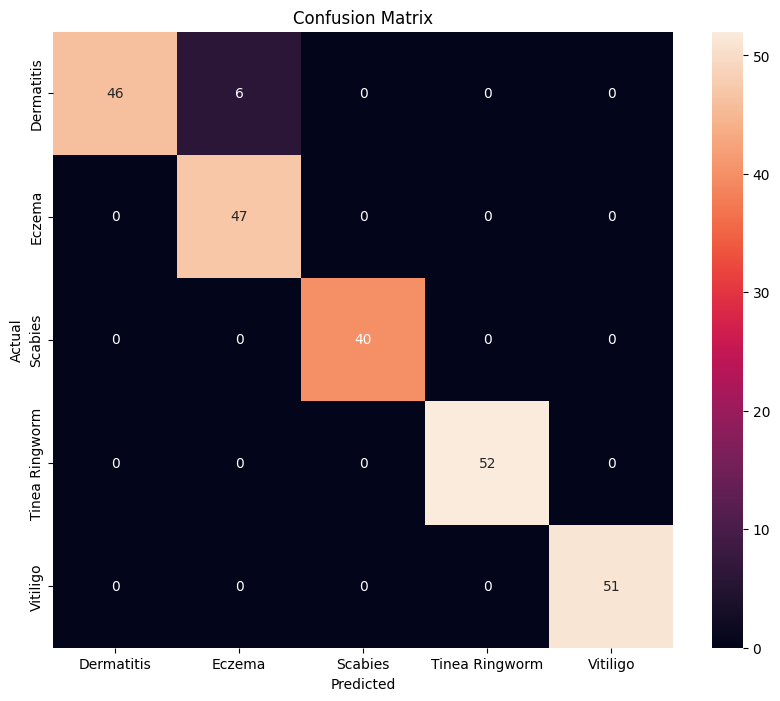


TEST RESULTS
Accuracy : 0.9876
Precision: 0.9880
Recall   : 0.9876
F1 Score : 0.9876

Classification Report:
                precision    recall  f1-score   support

    Dermatitis       1.00      0.97      0.99        35
        Eczema       0.97      1.00      0.98        56
       Scabies       0.98      1.00      0.99        44
Tinea Ringworm       1.00      0.96      0.98        52
      Vitiligo       1.00      1.00      1.00        55

      accuracy                           0.99       242
     macro avg       0.99      0.99      0.99       242
  weighted avg       0.99      0.99      0.99       242



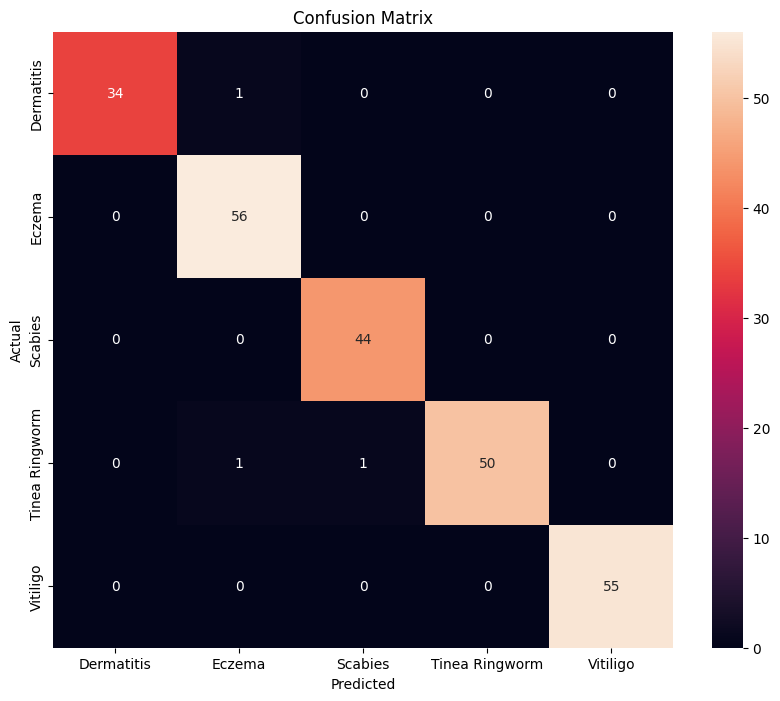

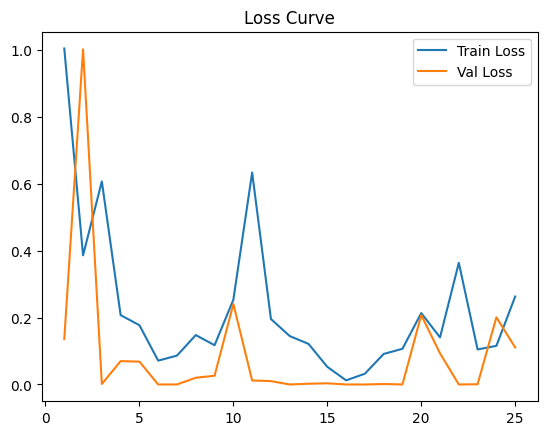

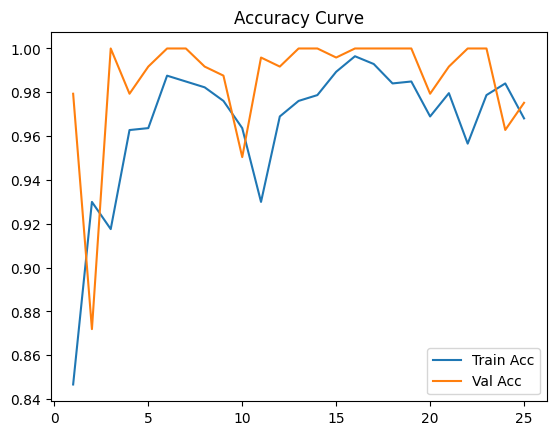

In [12]:
history = train_model(model, train_loader, val_loader, epochs=25)

cm_val = evaluate_model(model, val_loader, class_names, "VALIDATION")
plot_confusion_matrix(cm_val, class_names)

cm_test = evaluate_model(model, test_loader, class_names, "TEST")
plot_confusion_matrix(cm_test, class_names)

plot_training_curves(history)

In [13]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 19.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [14]:
# =========================
# GRAD-CAM (EXPLAINABILITY)
# =========================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

CAM range: 0.0 0.9999999


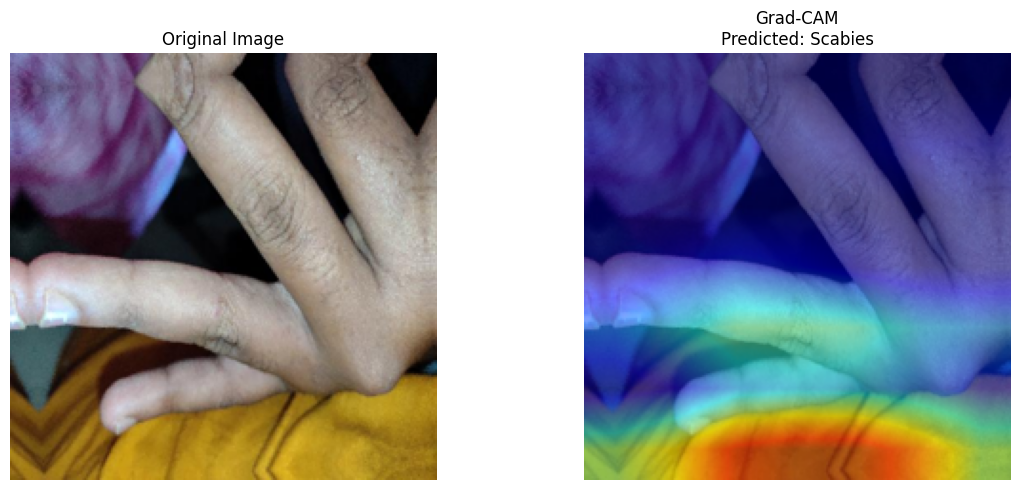

In [15]:
# =========================
# GRAD-CAM (FIXED)
# =========================

model.eval()

# ✅ FIX 1: Better target layer
target_layers = [model.blocks[-1]]

# =========================
# LOAD IMAGE
# =========================
img_path = test_dataset.dataset.samples[test_dataset.indices[18]][0]

image = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)

# ✅ FIX 2: Correct image format for visualization
rgb_img = np.array(image.resize((224,224))).astype(np.float32) / 255.0

# =========================
# PREDICTION
# =========================
outputs = model(input_tensor)
pred_class = outputs.argmax(dim=1).item()

# =========================
# GRAD-CAM
# =========================
cam = GradCAM(model=model, target_layers=target_layers)

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# ✅ DEBUG (very important)
print("CAM range:", grayscale_cam.min(), grayscale_cam.max())

# =========================
# VISUALIZATION (SIDE BY SIDE)
# =========================

# Generate overlay
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True,
    image_weight=0.5
)

# Plot side-by-side
plt.figure(figsize=(12,5))

# 🔹 Original Image
plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis('off')

# 🔹 Grad-CAM Image
plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title(f"Grad-CAM\nPredicted: {class_names[pred_class]}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
torch.save(model.state_dict(), "model.pth")

In [17]:
import os

print("Original model size:", os.path.getsize("model.pth")/1e6, "MB")

Original model size: 17.026707 MB


In [18]:
import time

model.eval()

input_tensor = torch.randn(1,3,224,224).to(device)

start = time.time()
model(input_tensor)
end = time.time()

print("Inference time:", end - start, "seconds")

Inference time: 0.015345573425292969 seconds
